# HMC with exact Fourier acceleration: harmonic and quartic rings

Implementation of Algorithms 1–3 in Johann Ostmeyer, *The Physicist's Guide to the HMC*, [arXiv:2501.19130v1](https://arxiv.org/abs/2501.19130v1), pp. 3–4.


## Model and conventions

For a ring of $N$ real variables, $x_N=x_0$,
$$S(x)=\frac12\sum_{j=0}^{N-1}\left[m^2x_j^2+\kappa(x_{j+1}-x_j)^2\right]
+\frac g4\sum_{j=0}^{N-1}x_j^4.$$

Use $m^2>0$, $\kappa\geq0$ and $g\geq0$. The harmonic case has $g=0$; the second case uses a small positive $g$.
The Fourier eigenvalues are $\lambda_k=m^2+4\kappa\sin^2(\pi k/N)$, equal to the paper's $\omega_k^2$.

The kinetic energy is $K=p^TM^{-1}p/2$. $M$, $M^{-1}$ and $\sqrt M$ are in fourier basis. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True, "grid.alpha": 0.25})

# Editable model and sampling parameters.
N = 32
mass_squared = 1.0
kappa = 1.0
g_quartic = 5.0
trajectory_length = np.pi / 2

n_thermalisation = 500 
n_samples = 12_000 
seed = 20261001

## Action, forces and Fourier operations

The quartic convention is $V=g\sum_jx_j^4/4$, so $\nabla V=gx^3$ componentwise. Setting $N=1$ gives one oscillator; setting $\kappa=0$ gives independent oscillators.

In [4]:
def harmonic_eigenvalues(n_sites, mass_squared=1.0, kappa=1.0):
    """Calculate the eigenvalues of pure harmonic action, PBC."""
    if not isinstance(n_sites, (int, np.integer)) or n_sites < 1:
        raise ValueError("n_sites must be a positive integer")
    if not (np.isfinite(mass_squared) and mass_squared > 0):
        raise ValueError("mass_squared must be finite and positive (no free zero mode)")
    if not (np.isfinite(kappa) and kappa >= 0):
        raise ValueError("kappa must be finite and non-negative")
    modes = np.arange(n_sites)
    return mass_squared + 4 * kappa * np.sin(np.pi * modes / n_sites)**2


def fourier_apply(vector, multiplier):
    """Apply a real Fourier-diagonal operator to a real ring configuration.
    Multiplier: in Fourier space, e.g. eigenvalues of the kinetic operator.
    Vector: in real space, e.g. a configuration of the field on the ring.
    Output: in real space, e.g. the result of applying the operator to the configuration.
    """
    modes = np.fft.fft(vector, norm="ortho")
    return np.fft.ifft(multiplier * modes, norm="ortho").real


def V_anharmonic_potential(x, g):
    return 0.25 * g * np.sum(x**4)

def V_gradient(x, g):
    return g * x**3

def S_action(x, eigenvalues, g=0.0):
    return 0.5 * np.dot(x, fourier_apply(x, eigenvalues)) + V_anharmonic_potential(x, g)


def kinetic_energy(p, eigenvalues):
    return 0.5 * np.dot(p, fourier_apply(p, 1.0 / eigenvalues))


def H_hamiltonian(x, p, eigenvalues, g=0.0):
    return kinetic_energy(p, eigenvalues) + S_action(x, eigenvalues, g)


eigenvalues = harmonic_eigenvalues(N, mass_squared, kappa)

## Algorithm 3: exact harmonic evolution

In each mode, advance $y_k$ and $q_k$ with the paper's cosine/sine rotation. Both new arrays use the original mode coordinates.

After fourier transformation to the **hamornic hamitonian**
$$
\boxed{
H_0
=\frac12\sum_k
\left(
\frac{|q_k|^2}{\lambda_k}
+\lambda_k|y_k|^2
\right).
}
$$

This simplifies the equation of motion to scalar relations. 

$$
\boxed{
\dot y_k=\frac{q_k}{\lambda_k},
\qquad
\dot q_k=-\lambda_k y_k.
}
$$
Each mode now evolves without involving any other mode, and 
and
$$
\ddot y_k=\frac{\dot q_k}{\lambda_k}=-y_k.
$$
which is easily solvable. 

In [5]:
def efa_step(x, p, step_size, eigenvalues):
    """Algorithm 3: exact flow of K(p) + x.T @ M @ x / 2."""
    y = np.fft.fft(x, norm="ortho")
    q = np.fft.fft(p, norm="ortho")
    c, s = np.cos(step_size), np.sin(step_size)
    y_new = c * y + s  * (q/ eigenvalues)
    q_new = c * q - s * (eigenvalues * y)
    x_new = np.fft.ifft(y_new, norm="ortho").real
    p_new = np.fft.ifft(q_new, norm="ortho").real
    return x_new, p_new

## Algorithm 2: EFA leapfrog

Exact harmonic half-step → quartic momentum kick → exact harmonic half-step. The harmonic flow is exact; the split flow for $g>0$ has finite-step error.

In [7]:
def leapfrog_efa(x, p, step_size, eigenvalues, g=0.0):
    """Algorithm 2: symmetric harmonic / anharmonic / harmonic splitting."""
    x, p = efa_step(x, p, 0.5 * step_size, eigenvalues)
    p = p - step_size * V_gradient(x, g)
    return efa_step(x, p, 0.5 * step_size, eigenvalues)


def integrate_trajectory(x, p, eigenvalues, g, n_steps, length=np.pi / 2):
    if not isinstance(n_steps, (int, np.integer)) or n_steps < 1:
        raise ValueError("n_steps must be a positive integer")
    if not (np.isfinite(length) and length > 0):
        raise ValueError("length must be finite and positive")
    x, p = np.array(x, dtype=float, copy=True), np.array(p, dtype=float, copy=True)
    h = length / n_steps
    for _ in range(n_steps):
        x, p = leapfrog_efa(x, p, h, eigenvalues, g)
    return x, p

## Algorithm 1: refresh, trajectory and Metropolis filter

Generate $p=\sqrt M\,r$ with $r\sim\mathcal N(0,I)$. Evaluate the **original** Hamiltonian at both endpoints. Fresh momentum is drawn on every update; its final sign is irrelevant because it is discarded. Rejected configurations are retained as repeated samples.

In [8]:
def hmc_update(x, eigenvalues, g, n_steps, rng, length=np.pi / 2):
    """Perform one HMC trajectory, following Algorithm 1."""

    # Draw fresh momentum: p = sqrt(M) r.
    r = rng.normal(size=x.size)
    p = fourier_apply(r, np.sqrt(eigenvalues))

    #  Calculate the initial Hamiltonian.
    H_initial = 0.5 * np.dot(r, r) + S_action(x, eigenvalues, g)

    # Integrate the trajectory.
    x_trial, p_trial = integrate_trajectory(
        x, p, eigenvalues, g, n_steps, length
    )

    # Calculate the change in Hamiltonian.
    H_final = H_hamiltonian(x_trial, p_trial, eigenvalues, g)
    delta_H = H_final - H_initial

    # Metropolis filter.
    if delta_H <= 0:
        acceptance_probability = 1.0
    else:
        acceptance_probability = np.exp(-delta_H)

    accepted = rng.random() < acceptance_probability

    if accepted:
        x = x_trial

    return x, accepted, delta_H


def run_chain(
    eigenvalues, g, n_steps, n_samples, n_thermalisation, seed,
    length=np.pi / 2, x_initial=None
):
    """Thermalise, then collect one configuration after each HMC update."""
    rng = np.random.default_rng(seed)

    if x_initial is None:
        x = np.zeros(len(eigenvalues))
    else:
        x = np.array(x_initial, dtype=float, copy=True)

    # Thermalisation: update x without storing configurations.
    warm_accepts = 0

    for _ in range(n_thermalisation):
        x, accept, _ = hmc_update(
            x, eigenvalues, g, n_steps, rng, length
        )
        warm_accepts += accept

    # Sampling: store every configuration, including rejected repeats.
    samples = np.empty((n_samples, len(x)))
    accepted = np.empty(n_samples, dtype=bool)
    delta_h = np.empty(n_samples)

    for i in range(n_samples):
        x, accept, dh = hmc_update(
            x, eigenvalues, g, n_steps, rng, length
        )

        samples[i] = x
        accepted[i] = accept
        delta_h[i] = dh

    warm_acceptance = np.nan
    if n_thermalisation > 0:
        warm_acceptance = warm_accepts / n_thermalisation

    return {
        "samples": samples,
        "accepted": accepted,
        "delta_h": delta_h,
        "warm_acceptance": warm_acceptance,
    }

## sanity checks

Check the real-space action against the Fourier implementation, the quartic force, harmonic energy conservation, reversibility and the quarter-period endpoint.

In [9]:
check_rng = np.random.default_rng(seed + 10)
x_test = check_rng.normal(size=N)
p_test = check_rng.normal(size=N)

s_real = (0.5 * mass_squared * np.sum(x_test**2)
          + 0.5 * kappa * np.sum((np.roll(x_test, -1) - x_test)**2)
          + V_anharmonic_potential(x_test, g_quartic))
assert np.isclose(S_action(x_test, eigenvalues, g_quartic), s_real)

eps = 1e-6
force_fd = np.empty(N)
for j in range(N):
    shift = np.zeros(N)
    shift[j] = eps
    force_fd[j] = (V_anharmonic_potential(x_test + shift, g_quartic)
                   - V_anharmonic_potential(x_test - shift, g_quartic)) / (2 * eps)
assert np.allclose(force_fd, V_gradient(x_test, g_quartic), atol=2e-8, rtol=1e-6)

x_end, p_end = efa_step(x_test, p_test, 0.73, eigenvalues)
harmonic_energy_error = abs(H_hamiltonian(x_end, p_end, eigenvalues)
                            - H_hamiltonian(x_test, p_test, eigenvalues))
assert harmonic_energy_error < 1e-10

x_end, p_end = integrate_trajectory(x_test, p_test, eigenvalues, g_quartic, 7)
x_back, p_back = integrate_trajectory(x_end, -p_end, eigenvalues, g_quartic, 7)
reversal_error = max(np.max(abs(x_back - x_test)), np.max(abs(p_back + p_test)))
assert reversal_error < 1e-10

x_quarter, _ = efa_step(x_test, p_test, np.pi / 2, eigenvalues)
assert np.allclose(x_quarter, fourier_apply(p_test, 1 / eigenvalues), atol=1e-12)
print(f"Deterministic checks passed. Harmonic |ΔH| = {harmonic_energy_error:.2e}; "
      f"reversal error = {reversal_error:.2e}")

Deterministic checks passed. Harmonic |ΔH| = 7.11e-15; reversal error = 8.22e-15


### Why is it called fourier acceleration? 
One EFA step: $O(N \log{N})$

One HMC step: $O(N)$

## Sample both rings

The harmonic case needs only one molecular-dynamics step at $T=\pi/2$. The quartic case uses several steps. Increase `n_md_quartic` if acceptance is poor; keep the trajectory length fixed for these examples.

In [ ]:
n_steps_harmonic = 1
n_steps_quartic = 30


harmonic = run_chain(eigenvalues, 0.0, n_steps_harmonic, n_samples, n_thermalisation,
                    seed, trajectory_length)
quartic = run_chain(eigenvalues, g_quartic, n_steps_quartic, n_samples, n_thermalisation,
                    seed + 1, trajectory_length)

for name, result in [("Harmonic", harmonic), ("Quartic", quartic)]:
    dh = result["delta_h"]
    print(f"{name:10s} acceptance = {result['accepted'].mean():.4f}; "
        f"RMS ΔH = {np.sqrt(np.mean(dh**2)):.3e}; "
        f"non-finite proposals = {np.count_nonzero(~np.isfinite(dh))}")

# First-order estimate of the quartic action relative to the harmonic action,
# evaluated in the harmonic Gaussian ensemble, not a uniform bound in x.
c0_exact = np.mean(1 / eigenvalues)
relative_quartic = 1.5 * g_quartic * c0_exact**2
print(f"Gaussian estimate <V>_0 / <S_0>_0 = {relative_quartic:.3%}")

Harmonic   acceptance = 1.0000; RMS ΔH = 1.890e-14; non-finite proposals = 0
Quartic    acceptance = 0.9974; RMS ΔH = 4.624e-03; non-finite proposals = 0
Gaussian estimate <V>_0 / <S_0>_0 = 150.000%


## Observables and checks against known results

For $g=0$, $\langle x_ix_j\rangle=(M^{-1})_{ij}$ and
$C(r)=\langle x_jx_{j+r}\rangle=N^{-1}\sum_k e^{2\pi i kr/N}/\lambda_k$.
For both models, integration by parts gives $\langle x\cdot\nabla S\rangle/N=1$.

Errors below use 40 contiguous batch means. These are approximate Monte Carlo uncertainties: batches must be long compared with the correlation time. Statistical checks are diagnostics, not proofs of convergence.

sampling autocorrelation of $x_0$
Set
$$
a_n=x_0^{(n)},\qquad
\bar a=\frac1{N_s}\sum_n a_n.
$$
The code estimates
$$
\widehat\Gamma(\ell)
=\frac1{N_s-\ell}
\sum_{n=1}^{N_s-\ell}
(a_n-\bar a)(a_{n+\ell}-\bar a),
$$
then normalises:
$$
\boxed{\widehat\rho(\ell)
=\frac{\widehat\Gamma(\ell)}{\widehat\Gamma(0)}.}
$$
Thus $\rho(0)=1$. Rapid decay towards zero means successive values of this observable lose memory quickly.

In [18]:
def batch_mean_error(values, n_batches=40):
    values = np.asarray(values)
    batch_size = len(values) // n_batches
    if batch_size < 2:
        raise ValueError("Too few samples for the requested batches")
    batch_means = values[:batch_size * n_batches].reshape(n_batches, batch_size).mean(axis=1)
    return values.mean(), batch_means.std(ddof=1) / np.sqrt(n_batches)

def ring_correlation(samples):
    modes = np.fft.fft(samples, axis=1, norm="ortho")
    power = np.mean(abs(modes)**2, axis=0)
    return np.fft.ifft(power).real, power

def autocorrelation(values, max_lag=40):
    centred = np.asarray(values) - np.mean(values)
    n = len(centred)
    transform = np.fft.rfft(centred, n=2*n)
    covariance = np.fft.irfft(abs(transform)**2, n=2*n)[:max_lag+1]
    covariance /= n - np.arange(max_lag+1)
    return covariance / covariance[0]

correlation_exact = np.fft.ifft(1 / eigenvalues).real
for name, result, g in [("Harmonic", harmonic, 0.0), ("Quartic", quartic, g_quartic)]:
    samples = result["samples"]
    modes = np.fft.fft(samples, axis=1, norm="ortho")
    virial = (np.sum(abs(modes)**2 * eigenvalues, axis=1)
              + g * np.sum(samples**4, axis=1)) / N 
    x2, x2_error = batch_mean_error(np.mean(samples**2, axis=1))
    v_mean, v_error = batch_mean_error(virial)
    print(f"{name:10s} <x²> = {x2:.6f} ± {x2_error:.6f}; "
          f"<x·∇S>/N = {v_mean:.6f} ± {v_error:.6f} (target 1)")
print(f"Harmonic exact <x²> = {c0_exact:.6f}")

# A full covariance check: whiten with sqrt(M), then compare to the identity.
z_samples = np.fft.ifft(np.fft.fft(harmonic["samples"], axis=1, norm="ortho")
                        * np.sqrt(eigenvalues), axis=1, norm="ortho").real
white_covariance = z_samples.T @ z_samples / n_samples
print(f"Harmonic max |whitened second moment - I| = "
      f"{np.max(abs(white_covariance - np.eye(N))):.4f}")

Harmonic   <x²> = 0.446067 ± 0.001102; <x·∇S>/N = 0.997602 ± 0.001836 (target 1)
Quartic    <x²> = 0.196115 ± 0.000878; <x·∇S>/N = 0.989153 ± 0.006126 (target 1)
Harmonic exact <x²> = 0.447214
Harmonic max |whitened second moment - I| = 0.0298


## Compare the samples

The dotted/solid analytic curves apply only to the harmonic target. The quartic histogram and correlations are numerical estimates. The autocorrelation plot uses trajectory index, including rejected repeats.

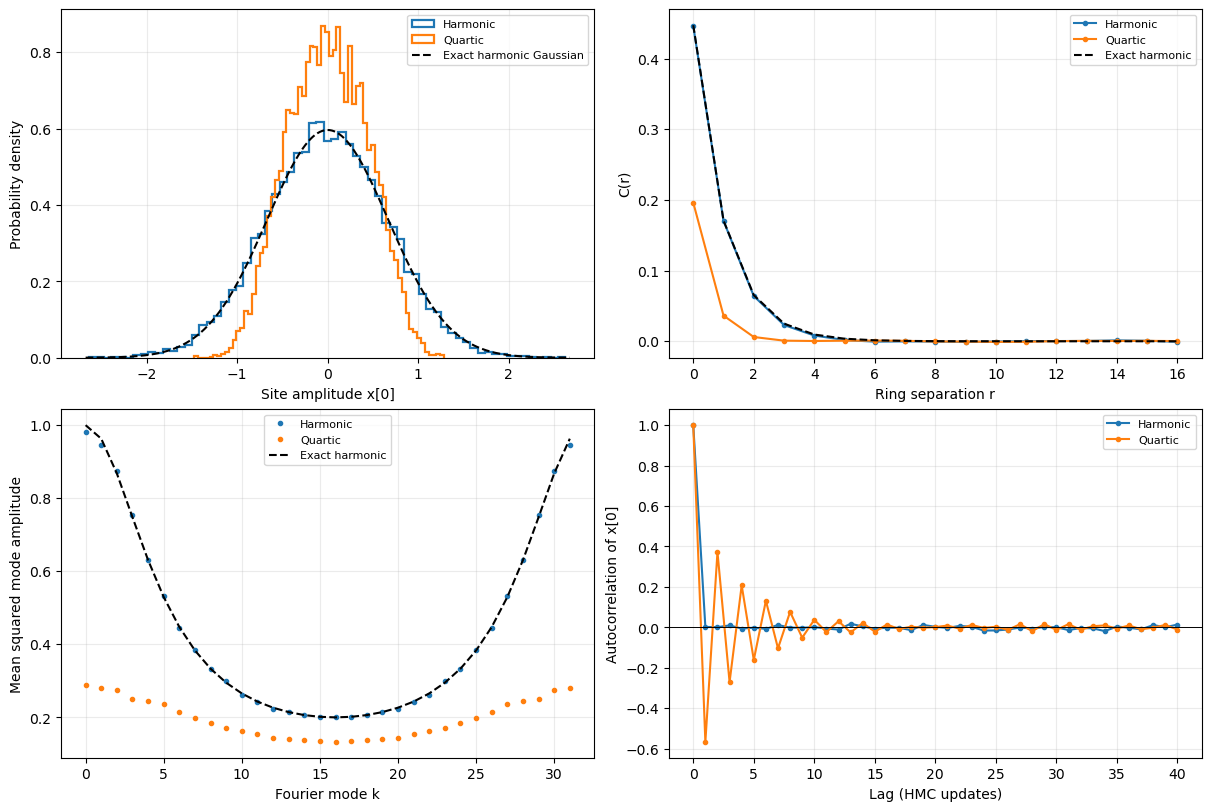

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
colours = {"Harmonic": "tab:blue", "Quartic": "tab:orange"}
for name, result in [("Harmonic", harmonic), ("Quartic", quartic)]:
    samples = result["samples"]
    colour = colours[name]
    axes[0, 0].hist(samples[:, 0], bins=65, density=True, histtype="step",
                    linewidth=1.6, label=name, color=colour)
    corr, power = ring_correlation(samples)
    distances = np.arange(N // 2 + 1)
    axes[0, 1].plot(distances, corr[distances], "o-", ms=3, label=name, color=colour)
    axes[1, 0].plot(np.arange(N), power, "o", ms=3, label=name, color=colour)
    acf = autocorrelation(samples[:, 0])
    axes[1, 1].plot(np.arange(len(acf)), acf, ".-", label=name, color=colour)

grid = np.linspace(-4*np.sqrt(c0_exact), 4*np.sqrt(c0_exact), 400)
axes[0, 0].plot(grid, np.exp(-grid**2/(2*c0_exact))/np.sqrt(2*np.pi*c0_exact),
                "k--", label="Exact harmonic Gaussian")
axes[0, 1].plot(distances, correlation_exact[distances], "k--", label="Exact harmonic")
axes[1, 0].plot(np.arange(N), 1/eigenvalues, "k--", label="Exact harmonic")
axes[1, 1].axhline(0, color="black", linewidth=0.7)
axes[0, 0].set(xlabel="Site amplitude x[0]", ylabel="Probability density")
axes[0, 1].set(xlabel="Ring separation r", ylabel="C(r)")
axes[1, 0].set(xlabel="Fourier mode k", ylabel="Mean squared mode amplitude")
axes[1, 1].set(xlabel="Lag (HMC updates)", ylabel="Autocorrelation of x[0]")
for ax in axes.flat:
    ax.legend(fontsize=8)
plt.show()